# Step 1 – Data Import & Exploration
Import the dataset and examine its structure, dimensions, data types, and data quality before any analysis.

In [1]:
# Cell 1 – Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import missingno as msno

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import xgboost as xgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings('ignore')

# Custom functions for evaluation
def nse(predictions, targets):
    return (1 - (np.sum((predictions - targets) ** 2) / np.sum((targets - np.mean(targets)) ** 2)))

def rmse(predictions, targets):
    return np.sqrt(mean_squared_error(predictions, targets))

In [2]:
# Cell 2 – Load & Explore Dataset
df = pd.read_csv('final_data_physics_baseline/phy_final_corrected_data.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
display(df.head())
df.info()

Shape: (306, 11)
Columns: ['Unnamed: 0.1', 'Unnamed: 0', 'dewpoint', 'et_loss', 'ndvi', 'precipitation', 'radiation', 'sca', 'dd', 'temp', 'runoff']


,Unnamed: 0.1,Unnamed: 0,dewpoint,et_loss,ndvi,precipitation,radiation,sca,dd,temp,runoff
date,,,,,,,,,,,
2000-06-30,0,0,270.274111,0.035384,0.167895,1.081265,8552.215167,15695.091988,0.000000,255.924696,0.959289
2000-07-31,1,1,275.634907,0.005471,0.214835,2.074423,8945.476526,6188.434963,0.000000,253.865719,0.515886
2000-08-31,2,2,273.643363,0.016486,0.171795,1.208544,8787.250911,10114.130241,0.000000,258.913569,0.355015
2000-09-30,3,3,266.780844,0.040531,0.148384,0.857759,7687.016192,12888.810599,0.000000,265.094486,0.186357
2000-10-31,4,4,259.412862,0.029951,0.113129,0.231264,5685.865842,19583.623736,0.551964,273.551964,0.138155


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 306 entries, 2000-06-30 to 2025-11-30
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0.1   306 non-null    int64  
 1   Unnamed: 0     306 non-null    int64  
 2   dewpoint       306 non-null    float64
 3   et_loss        306 non-null    float64
 4   ndvi           306 non-null    float64
 5   precipitation  306 non-null    float64
 6   radiation      306 non-null    float64
 7   sca            306 non-null    float64
 8   dd             306 non-null    float64
 9   temp           306 non-null    float64
 10  runoff         306 non-null    float64
dtypes: float64(9), int64(2)
memory usage: 28.7 KB


In [3]:
# Describe numerical columns
display(df.describe())

,Unnamed: 0.1,Unnamed: 0,dewpoint,et_loss,ndvi,precipitation,radiation,sca,dd,temp,runoff
count,306.000000,306.000000,306.000000,3.060000e+02,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000
mean,152.500000,152.500000,260.204040,4.897667e-02,0.281527,0.899558,4766.153318,28064.896687,1.973379,267.537885,0.503403
std,88.478811,88.478811,9.356982,3.407956e-02,0.125110,0.786415,2687.884601,12115.442127,3.266650,9.414784,0.723346
min,0.000000,0.000000,244.182792,1.233960e-11,0.060334,0.024735,1169.768120,5300.632089,0.000000,252.447712,0.029289
25%,76.250000,76.250000,251.695580,2.163164e-02,0.172804,0.298468,2214.416509,18397.686028,0.000000,258.834349,0.063727
50%,152.500000,152.500000,259.381040,4.165413e-02,0.240190,0.698135,4171.281813,27202.299004,0.000000,266.584307,0.151048
75%,228.750000,228.750000,268.515510,7.125847e-02,0.393557,1.214406,7369.761084,36316.956525,3.477651,276.477651,0.622741
max,305.000000,305.000000,276.245179,1.488600e-01,0.546876,4.527822,9759.438905,60577.019749,10.742527,283.742527,3.351402


# Step 2 – Visualise Missing Values

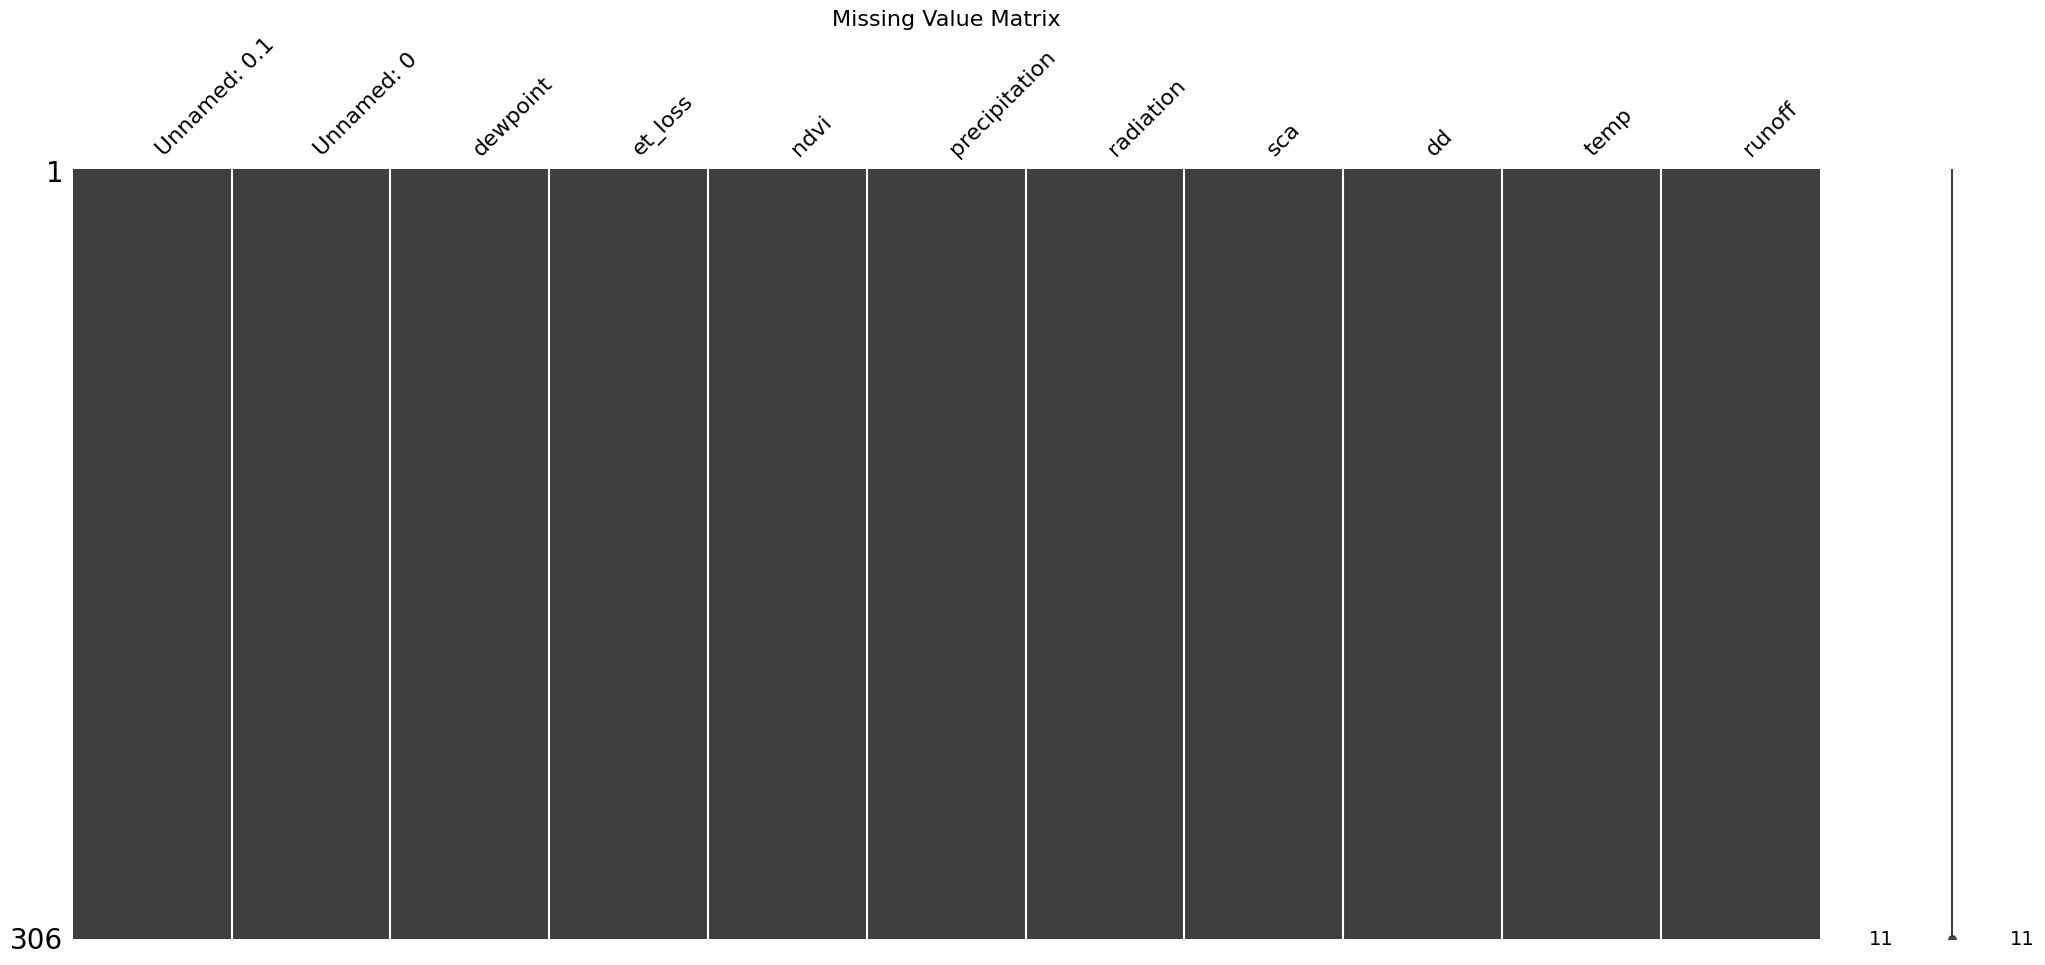

In [4]:
# Cell 3 – Missing Value Matrix
# Visualize missing values as a matrix
msno.matrix(df)
plt.title('Missing Value Matrix', fontsize=16)
plt.show()

# Step 3 – Data Manipulation & Feature Engineering
Clean the dataset, drop unnecessary columns, fix data types, and create analysis-ready features.

In [5]:
# Cell 4 – Feature Engineering with Lagged Variables
def create_lag_adv(df, lag_days_list, cols_to_lag):
    """
    Creates lagged features for specified columns in a DataFrame.
    This version avoids in-place modification and returns a new DataFrame.
    """
    df_new = df.copy()
    for lag_days in lag_days_list:
        for col in cols_to_lag:
            df_new[f'{col}_lag{lag_days}'] = df_new[col].shift(lag_days)
    
    # Create interaction terms for melt proxy
    for sca_lag in lag_days_list:
        for dd_lag in lag_days_list:
            # Only create physically meaningful interactions (sca_lag >= dd_lag)
            if sca_lag >= dd_lag:
                sca_col = f'sca_lag{sca_lag}'
                dd_col = f'dd_lag{dd_lag}'
                if sca_col in df_new.columns and dd_col in df_new.columns:
                    df_new[f'melt_proxy_{sca_lag}_{dd_lag}'] = df_new[sca_col] * df_new[dd_col]
    
    return df_new

# Define columns and lags
cols_to_lag = ['precipitation', 'temp', 'sca', 'dd']
lag_days_list = [1, 2, 3, 12] # Example lags in months

# Create the new dataframe with lagged features
df_lagged = create_lag_adv(df, lag_days_list, cols_to_lag)

# Drop rows with NaN values created by shifting
df_lagged = df_lagged.dropna()

print("Shape of dataframe with lagged features:", df_lagged.shape)
df_lagged.head()

Shape of dataframe with lagged features: (294, 37)


,Unnamed: 0.1,Unnamed: 0,dewpoint,et_loss,ndvi,precipitation,radiation,sca,dd,temp,...,melt_proxy_1_1,melt_proxy_2_1,melt_proxy_2_2,melt_proxy_3_1,melt_proxy_3_2,melt_proxy_3_3,melt_proxy_12_1,melt_proxy_12_2,melt_proxy_12_3,melt_proxy_12_12
date,,,,,,,,,,,,,,,,,,,,,
2001-06-30,12,12,270.580472,0.023075,0.132721,1.281269,8710.314213,19325.238538,0.0,253.748642,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2001-07-31,13,13,274.919120,0.009803,0.187431,2.670640,8963.744605,10008.670847,0.0,256.358244,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2001-08-31,14,14,272.760821,0.017714,0.144502,0.986560,9263.307579,9942.814733,0.0,258.947447,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2001-09-30,15,15,265.737820,0.043539,0.148376,0.686996,7476.278338,14999.819314,0.0,266.093773,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2001-10-31,16,16,258.730367,0.042816,0.128725,0.260683,5959.298979,27495.641845,0.0,272.395143,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10809.451022


# Step 4 – Exploratory Data Analysis
Visualise distributions, correlations, and patterns to understand how features relate to the runoff target.

In [6]:
# Cell 5 - Time Series Plot of Runoff
px.line(df, y='runoff', title='Monthly Runoff at Tarbela')

In [7]:
# Cell 6 - Plotting other key variables
fig = make_subplots(rows=3, cols=1, shared_xaxes=True, subplot_titles=('Precipitation', 'Temperature', 'Snow Covered Area (SCA)'))
fig.add_trace(go.Scatter(x=df.index, y=df['precipitation'], mode='lines', name='Precipitation'), row=1, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df['temp'], mode='lines', name='Temperature'), row=2, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df['sca'], mode='lines', name='SCA'), row=3, col=1)
fig.update_layout(height=600, title_text="Key Climate Variables Over Time")
fig.show()

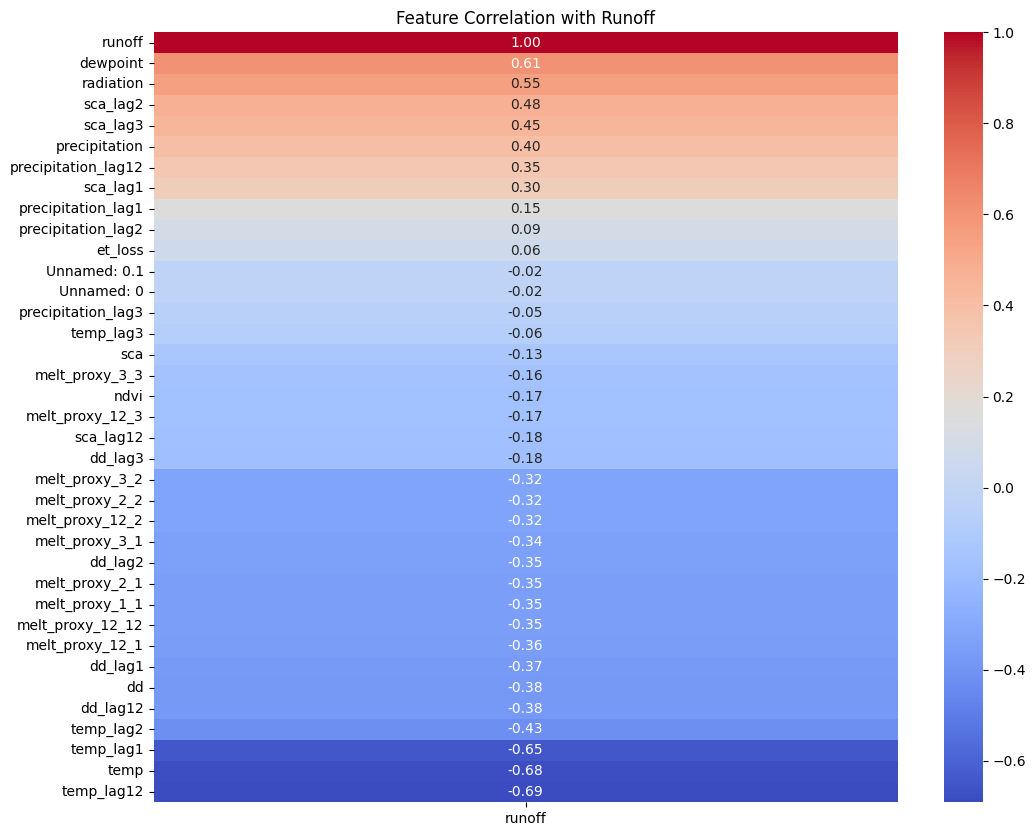

In [8]:
# Cell 7 – Correlation Heatmap
plt.figure(figsize=(12, 10))
# We will correlate with the target variable 'runoff'
corr = df_lagged.corr()[['runoff']].sort_values(by='runoff', ascending=False)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation with Runoff');
plt.show()

# Step 5 – Data Preprocessing & Baseline Model

In [9]:
# Cell 8 – Train-Validation-Test Split
# Define the split points
train_end = '2010-12-31'
val_end = '2017-12-31'
test_start = '2018-01-01'

# Split the data into training, validation, and testing sets
train_df = df_lagged.loc[:train_end]
val_df = df_lagged.loc[train_end:val_end]
test_df = df_lagged.loc[test_start:]

print('Train Shape:', train_df.shape)
print('Validation Shape:', val_df.shape)
print('Test Shape:', test_df.shape)

Train Shape: (115, 37)
Validation Shape: (85, 37)
Test Shape: (95, 37)


In [10]:
# Cell 9 - Linear Regression Model
# Define features (X) and target (y)
features = [col for col in train_df.columns if col != 'discharge']
X_train, y_train = train_df[features], train_df['discharge']
X_val, y_val = val_df[features], val_df['discharge']
X_test, y_test = test_df[features], test_df['discharge']

# Initialize and train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = lr_model.predict(X_test)

# Evaluate the model
r2_lr = r2_score(y_test, y_pred_lr)
print(f'Linear Regression R-squared: {r2_lr:.4f}')

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(test_df.index, y_test, label='Actual Discharge')
plt.plot(test_df.index, y_pred_lr, label='Predicted Discharge (LR)', linestyle='--')
plt.title('Linear Regression: Actual vs. Predicted Discharge')
plt.xlabel('Date')
plt.ylabel('Discharge')
plt.legend()
plt.grid(True)
plt.show()

KeyError: 'discharge'

In [ ]:
# Cell 10 - XGBoost Model
# Initialize and train the XGBoost model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=1000, learning_rate=0.05, max_depth=5, subsample=0.8, colsample_bytree=0.8, random_state=42)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], early_stopping_rounds=50, verbose=False)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model
r2_xgb = r2_score(y_test, y_pred_xgb)
print(f'XGBoost R-squared: {r2_xgb:.4f}')

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(test_df.index, y_test, label='Actual Discharge')
plt.plot(test_df.index, y_pred_xgb, label='Predicted Discharge (XGB)', linestyle='--')
plt.title('XGBoost: Actual vs. Predicted Discharge')
plt.xlabel('Date')
plt.ylabel('Discharge')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Cell 11 - Data Scaling for LSTM
# Scale the features for the LSTM model
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Reshape the data for LSTM (samples, timesteps, features)
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_val_lstm = X_val_scaled.reshape((X_val_scaled.shape[0], 1, X_val_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

In [ ]:
# Cell 12 - LSTM Model
# Define the LSTM model architecture
lstm_model = Sequential()
lstm_model.add(LSTM(50, activation='relu', input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer='adam', loss='mse')

# Train the LSTM model
history = lstm_model.fit(X_train_lstm, y_train, epochs=50, batch_size=32, validation_data=(X_val_lstm, y_val), verbose=0, shuffle=False)

# Make predictions on the test set
y_pred_lstm_scaled = lstm_model.predict(X_test_lstm)
y_pred_lstm = y_pred_lstm_scaled * scaler.scale_[0] + scaler.min_[0] # Inverse transform predictions

# Evaluate the model
r2_lstm = r2_score(y_test, y_pred_lstm)
print(f'LSTM R-squared: {r2_lstm:.4f}')

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(test_df.index, y_test, label='Actual Discharge')
plt.plot(test_df.index, y_pred_lstm, label='Predicted Discharge (LSTM)', linestyle='--')
plt.title('LSTM: Actual vs. Predicted Discharge')
plt.xlabel('Date')
plt.ylabel('Discharge')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Cell 13 - Model Comparison
# Plot all model predictions against the actual discharge
plt.figure(figsize=(15, 8))
plt.plot(test_df.index, y_test, label='Actual Discharge', color='black', linewidth=2)
plt.plot(test_df.index, y_pred_lr, label=f'Linear Regression (R2: {r2_lr:.4f})', linestyle='--')
plt.plot(test_df.index, y_pred_xgb, label=f'XGBoost (R2: {r2_xgb:.4f})', linestyle='--')
plt.plot(test_df.index, y_pred_lstm, label=f'LSTM (R2: {r2_lstm:.4f})', linestyle='--')
plt.title('Comparison of Model Predictions')
plt.xlabel('Date')
plt.ylabel('Discharge')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
# Cell 9 - Baseline Model (Linear Regression)
# Define features (X) and target (y)
features = [col for col in df_lagged.columns if col != 'runoff' and 'proxy' not in col] # Start simple
target = 'runoff'

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

# Initialize and train the model
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

# Make predictions
baseline_preds_train = baseline_model.predict(X_train)
baseline_preds_test = baseline_model.predict(X_test)

# Evaluate
print("--- Baseline Model Evaluation ---")
print(f"Train NSE: {nse(baseline_preds_train, y_train):.3f}")
print(f"Test NSE: {nse(baseline_preds_test, y_test):.3f}")
print(f"Train RMSE: {rmse(baseline_preds_train, y_train):.3f}")
print(f"Test RMSE: {rmse(baseline_preds_test, y_test):.3f}")

--- Baseline Model Evaluation ---
Train NSE: 0.785
Test NSE: 0.494
Train RMSE: 0.356
Test RMSE: 0.459


In [13]:
# Cell 10 - Calculate Residuals
# Calculate residuals from the baseline model
train_residuals = y_train - baseline_preds_train
test_residuals = y_test - baseline_preds_test

print("Residuals calculated.")

Residuals calculated.


# Step 6 – Train Hybrid Models
Train more advanced models on the residuals of the baseline model.

In [14]:
# Cell 11 - Hybrid XGBoost Model
print("--- Hybrid XGBoost Model ---")
# Features for the residual model can be the same or a different set
xgb_features = [col for col in df_lagged.columns if col != 'runoff']

X_train_xgb, y_train_xgb = train_df[xgb_features], train_residuals
X_test_xgb, y_test_xgb = test_df[xgb_features], test_residuals

# Initialize and train the XGBoost model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror',
                             n_estimators=200,
                             max_depth=5,
                             learning_rate=0.1,
                             random_state=42)
xgb_model.fit(X_train_xgb, y_train_xgb)

# Predict the residuals
xgb_preds_residuals = xgb_model.predict(X_test_xgb)

# Final prediction is baseline + residual prediction
final_preds_xgb = baseline_preds_test + xgb_preds_residuals

# Evaluate the final hybrid model
print(f"Hybrid XGBoost Test NSE: {nse(final_preds_xgb, y_test):.3f}")
print(f"Hybrid XGBoost Test RMSE: {rmse(final_preds_xgb, y_test):.3f}")

--- Hybrid XGBoost Model ---
Hybrid XGBoost Test NSE: 0.625
Hybrid XGBoost Test RMSE: 0.395
Hybrid XGBoost Test NSE: 0.625
Hybrid XGBoost Test RMSE: 0.395


In [15]:
# Cell 12 - Hybrid LSTM Model
print("\n--- Hybrid LSTM Model ---")

# Reshape data for LSTM [samples, time_steps, n_features]
X_train_lstm = X_train_xgb.values.reshape((X_train_xgb.shape[0], 1, X_train_xgb.shape[1]))
X_test_lstm = X_test_xgb.values.reshape((X_test_xgb.shape[0], 1, X_test_xgb.shape[1]))

# Scale the residuals (target for LSTM)
scaler = MinMaxScaler(feature_range=(0, 1))
y_train_lstm_scaled = scaler.fit_transform(y_train_xgb.values.reshape(-1, 1))

# Build LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(50, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
lstm_model.add(Dense(1))
lstm_model.compile(loss='mean_squared_error', optimizer='adam')

# Train the model
lstm_model.fit(X_train_lstm, y_train_lstm_scaled, epochs=50, batch_size=32, verbose=0)

# Predict scaled residuals and inverse transform
lstm_preds_residuals_scaled = lstm_model.predict(X_test_lstm)
lstm_preds_residuals = scaler.inverse_transform(lstm_preds_residuals_scaled)

# Final prediction
final_preds_lstm = baseline_preds_test + lstm_preds_residuals.flatten()

# Evaluate the final hybrid model
print(f"Hybrid LSTM Test NSE: {nse(final_preds_lstm, y_test):.3f}")
print(f"Hybrid LSTM Test RMSE: {rmse(final_preds_lstm, y_test):.3f}")


--- Hybrid LSTM Model ---
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Hybrid LSTM Test NSE: 0.320
Hybrid LSTM Test RMSE: 0.532
Hybrid LSTM Test NSE: 0.320
Hybrid LSTM Test RMSE: 0.532


# Step 7 – Evaluate & Visualise Results
Compare performance across models and visualise the predictions against the observed data.

In [16]:
# Cell 13 - Create a results DataFrame for plotting
results_df = pd.DataFrame({
    'Observed': y_test,
    'Baseline': baseline_preds_test,
    'Hybrid_XGB': final_preds_xgb,
    'Hybrid_LSTM': final_preds_lstm
}, index=y_test.index)

# Plot the results
fig = go.Figure()
fig.add_trace(go.Scatter(x=results_df.index, y=results_df['Observed'], mode='lines', name='Observed Discharge'))
fig.add_trace(go.Scatter(x=results_df.index, y=results_df['Baseline'], mode='lines', name='Baseline Model', line=dict(dash='dash')))
fig.add_trace(go.Scatter(x=results_df.index, y=results_df['Hybrid_XGB'], mode='lines', name='Hybrid XGBoost Model'))
fig.add_trace(go.Scatter(x=results_df.index, y=results_df['Hybrid_LSTM'], mode='lines', name='Hybrid LSTM Model'))

fig.update_layout(title='Model Prediction Performance on Test Data',
                  xaxis_title='Date',
                  yaxis_title='Discharge (m³/s)',
                  legend_title='Models')
fig.show()

<Figure size 1000x1200 with 0 Axes>

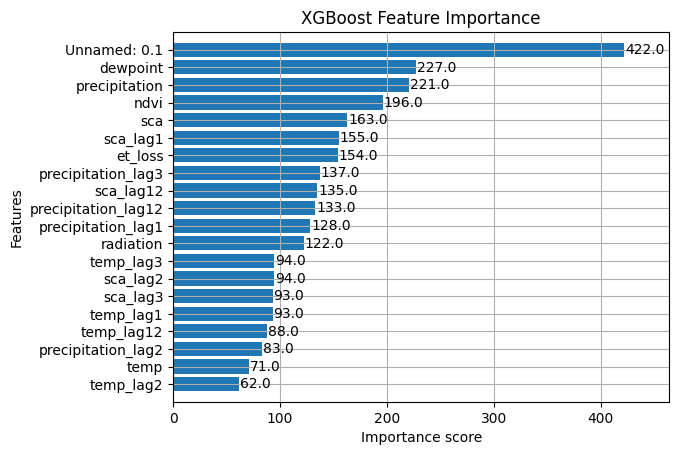

In [17]:
# Cell 14 - Feature Importance from XGBoost
plt.figure(figsize=(10, 12))
xgb.plot_importance(xgb_model, max_num_features=20, height=0.8)
plt.title('XGBoost Feature Importance')
plt.show()